Import all necessary libraries.

In [28]:
import pandas as pd
import numpy as np
import os
import wandb
import random
import math
import torch
import torch.nn as nn
from torch.nn.utils import clip_grad_norm_
from torch.utils.data import DataLoader
from imblearn.metrics import geometric_mean_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
from types import SimpleNamespace

from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_score

from sklearn.metrics import confusion_matrix
import seaborn as sns

import sys
sys.path.append(os.path.join(os.getcwd(), '../src'))

from transforms.feature_engineering_classification import add_all_features, filter_business_hours, entries_per_day_per_site
from transforms.feature_engineering_classification import (
    CONTINUOUS_FEATURE_COLUMNS,
    CATEGORICAL_FEATURE_COLUMNS,
    CYCLIC_FEATURE_COLUMNS,
    TARGET_COLUMN
)
from evaluation.comp_metrics import evaluate_all_metrics
from evaluation.visual import plot_confusion_matrix

from datasets.flextrack_dataset import FlextrackClassificationDataset
from utils.losses import FocalLoss

SWEEP = True

Set seed for reproducibility.

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [23]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
os.environ["WANDB_API_KEY"] = "3aaf9f796df65417b3f5f8560b43875171b55805"

wandb.login()

wandb: Currently logged in as: fabian-dubach (fabian-dubach-hochschule-luzern) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [4]:
# just use regression data and remove DR-Flags and DR-Capacity
df_train = pd.read_csv(os.path.normpath(os.path.join(os.getcwd(), '../data/regression/regression-train.csv')))
df_test = pd.read_csv(os.path.normpath(os.path.join(os.getcwd(), '../data/regression/regression-test.csv')))

In [5]:
print(f"Dataset shape: {df_train.shape}")
print(f"\nColumns: {df_train.columns.tolist()}")

Dataset shape: (105120, 7)

Columns: ['Site', 'Timestamp_Local', 'Dry_Bulb_Temperature_C', 'Global_Horizontal_Radiation_W/m2', 'Building_Power_kW', 'Demand_Response_Flag', 'Demand_Response_Capacity_kW']


# Feature Engineering

We use same feature engineering as in regression task but remove the irrelevant features.

In [6]:
df_train = add_all_features(df_train)
# TODO: add lag features for non sequence training (like for trees or tcn etc...)

df_train = filter_business_hours(df_train)

ENTRIES_PER_DAY = entries_per_day_per_site(df_train)

In [7]:
print(f"Dataset shape: {df_train.shape}")
print(f"\nColumns: {df_train.columns.tolist()}")

Dataset shape: (58035, 40)

Columns: ['Site', 'Timestamp_Local', 'Dry_Bulb_Temperature_C', 'Global_Horizontal_Radiation_W/m2', 'Building_Power_kW', 'Demand_Response_Flag', 'Demand_Response_Capacity_kW', 'hour', 'minute', 'day_of_week', 'is_weekend', 'is_holiday', 'month_sin', 'month_cos', 'Building_Power_kW_diff_15min', 'Building_Power_kW_diff_1h', 'Building_Power_kW_diff_1d', 'Dry_Bulb_Temperature_C_diff_15min', 'Global_Horizontal_Radiation_W/m2_diff_15min', 'Building_Power_kW_rolling_mean_1h', 'Building_Power_kW_rolling_mean_2h', 'Building_Power_kW_rolling_mean_1d', 'Building_Power_kW_rolling_std_1h', 'Building_Power_kW_rolling_std_2h', 'Building_Power_kW_rolling_std_1d', 'Building_Power_kW_rolling_min_1h', 'Building_Power_kW_rolling_min_2h', 'Building_Power_kW_rolling_max_1h', 'Building_Power_kW_rolling_max_2h', 'minute_0', 'minute_15', 'minute_30', 'minute_45', 'day_of_week_0', 'day_of_week_1', 'day_of_week_2', 'day_of_week_3', 'day_of_week_4', 'day_of_week_5', 'day_of_week_6']


# Split sites

In [8]:
def count_sites(df):

    counter_site_a = 0
    counter_site_b = 0
    counter_site_c = 0
    counter_site_d = 0
    counter_site_e = 0

    for i in df['Site']:
        if i == 'siteA':
            counter_site_a += 1
        elif i == 'siteB':
            counter_site_b += 1
        elif i == 'siteC':
            counter_site_c += 1
        elif i == 'siteD':
            counter_site_d += 1
        elif i == 'siteE':
            counter_site_e += 1
    
    return counter_site_a, counter_site_b, counter_site_c, counter_site_d, counter_site_e

In [9]:
df_train_site_a = df_train[0:19345]
count_sites(df_train_site_a)

df_train_site_b = df_train[19345:38690]
count_sites(df_train_site_b)

df_train_site_c = df_train[38690:58035]
count_sites(df_train_site_c)

(0, 0, 19345, 0, 0)

In [10]:
X_continuous_site_a = df_train_site_a[CONTINUOUS_FEATURE_COLUMNS].values # Convert to numpy array
X_continuous_site_b = df_train_site_b[CONTINUOUS_FEATURE_COLUMNS].values # Convert to numpy array
X_continuous_site_c = df_train_site_c[CONTINUOUS_FEATURE_COLUMNS].values # Convert to numpy array

X_categorical_site_a = df_train_site_a[CATEGORICAL_FEATURE_COLUMNS].values # Convert to numpy array
X_categorical_site_b = df_train_site_b[CATEGORICAL_FEATURE_COLUMNS].values # Convert to numpy array
X_categorical_site_c = df_train_site_c[CATEGORICAL_FEATURE_COLUMNS].values # Convert to numpy array

X_cyclic_site_a = df_train_site_a[CYCLIC_FEATURE_COLUMNS].values # Convert to numpy array
X_cyclic_site_b = df_train_site_b[CYCLIC_FEATURE_COLUMNS].values # Convert to numpy array
X_cyclic_site_c = df_train_site_c[CYCLIC_FEATURE_COLUMNS].values # Convert to numpy array

y_site_a = df_train_site_a[TARGET_COLUMN].values
y_site_b = df_train_site_b[TARGET_COLUMN].values
y_site_c = df_train_site_c[TARGET_COLUMN].values

In [11]:
print(f"Continuous feature shape: {X_continuous_site_a.shape}")
print(f"Continuous feature shape: {X_continuous_site_b.shape}")
print(f"Continuous feature shape: {X_continuous_site_c.shape}")

print(f"Categorical feature shape: {X_categorical_site_a.shape}")
print(f"Categorical feature shape: {X_categorical_site_b.shape}")
print(f"Categorical feature shape: {X_categorical_site_c.shape}")

print(f"Cyclic feature shape: {X_cyclic_site_a.shape}")
print(f"Cyclic feature shape: {X_cyclic_site_b.shape}")
print(f"Cyclic feature shape: {X_cyclic_site_c.shape}")

print(f"Target shape: {y_site_a.shape}")
print(f"Target shape: {y_site_b.shape}")
print(f"Target shape: {y_site_c.shape}")

Continuous feature shape: (19345, 19)
Continuous feature shape: (19345, 19)
Continuous feature shape: (19345, 19)
Categorical feature shape: (19345, 13)
Categorical feature shape: (19345, 13)
Categorical feature shape: (19345, 13)
Cyclic feature shape: (19345, 2)
Cyclic feature shape: (19345, 2)
Cyclic feature shape: (19345, 2)
Target shape: (19345,)
Target shape: (19345,)
Target shape: (19345,)


# Normalization

In [12]:
scaler_X_site_a = StandardScaler()
scaler_X_site_b = StandardScaler()
scaler_X_site_c = StandardScaler()

In [13]:
X_scaled_site_a = scaler_X_site_a.fit_transform(X_continuous_site_a)
X_scaled_site_b = scaler_X_site_b.fit_transform(X_continuous_site_b)
X_scaled_site_c = scaler_X_site_c.fit_transform(X_continuous_site_c)

Concatenate the unscaled and the scaled features together.

In [14]:
X_site_a = np.concatenate([X_scaled_site_a, X_categorical_site_a, X_cyclic_site_a], axis=1)
X_site_b = np.concatenate([X_scaled_site_b, X_categorical_site_b, X_cyclic_site_b], axis=1)
X_site_c = np.concatenate([X_scaled_site_c, X_categorical_site_c, X_cyclic_site_c], axis=1)

In [15]:
X_site_a = X_site_a.astype(np.float32)
X_site_b = X_site_b.astype(np.float32)
X_site_c = X_site_c.astype(np.float32)

y_site_a = y_site_a.astype(int)
y_site_b = y_site_b.astype(int)
y_site_c = y_site_c.astype(int)

In [17]:
print(f"All features shape: {X_site_a.shape}")
print(f"Target shape: {y_site_a.shape}")

All features shape: (19345, 34)
Target shape: (19345,)


In [18]:
np.unique(y_site_a)

array([0, 1, 2])

IMPORTANT: Remove entries, where features are incomplete (at start of dataset)

In [19]:
print("First few entries of each site have nan values due to feature engineering:\n", X_site_a[0])
print(X_site_a[ENTRIES_PER_DAY])

First few entries of each site have nan values due to feature engineering:
 [ 0.57910997 -1.3638599  -0.5221737  -0.00325376 -0.00751908         nan
 -0.69390106  0.0624692  -0.54411376 -0.5452835          nan -0.64983785
 -0.84162885         nan -0.38954532 -0.25569385 -0.6574576  -0.75812143
 -1.602483    1.          0.          0.          0.          0.
  1.          0.          0.          0.          0.          0.
  0.          1.          0.5         0.8660254 ]
[ 3.1494236e-01 -1.3638599e+00 -5.2217370e-01 -3.2537556e-03
 -7.5190784e-03  9.0518305e-03 -3.7747535e-01  6.2469199e-02
 -5.4411376e-01 -5.4528350e-01  2.9363585e+00 -6.4983785e-01
 -8.4162885e-01  4.3428288e+00 -3.8954532e-01 -2.5569385e-01
 -6.5745759e-01 -7.5812143e-01 -1.6024830e+00  1.0000000e+00
  0.0000000e+00  0.0000000e+00  0.0000000e+00  0.0000000e+00
  0.0000000e+00  1.0000000e+00  0.0000000e+00  0.0000000e+00
  0.0000000e+00  0.0000000e+00  0.0000000e+00  0.0000000e+00
  5.0000000e-01  8.6602539e-01]


In [20]:
# Create mask to exclude first ENTRIES_PER_DAY of each site
mask_site_a = np.ones(len(X_site_a), dtype=bool)
mask_site_b = np.ones(len(X_site_b), dtype=bool)
mask_site_c = np.ones(len(X_site_c), dtype=bool)

# Site A: exclude indices 0 to ENTRIES_PER_DAY-1
mask_site_a[0:ENTRIES_PER_DAY] = False

# Site B: exclude indices (365*ENTRIES_PER_DAY) to (365*ENTRIES_PER_DAY + ENTRIES_PER_DAY-1)
mask_site_b[0:ENTRIES_PER_DAY] = False

# Site C: exclude indices (730*ENTRIES_PER_DAY) to (730*ENTRIES_PER_DAY + ENTRIES_PER_DAY-1)
mask_site_c[0:ENTRIES_PER_DAY] = False

# Apply mask to remove incomplete entries
X_site_a = X_site_a[mask_site_a]
X_site_b = X_site_b[mask_site_b]
X_site_c = X_site_c[mask_site_c]

y_site_a = y_site_a[mask_site_a]
y_site_b = y_site_b[mask_site_b]
y_site_c = y_site_c[mask_site_c]

### Data Splitting

In [21]:
# Calculate split indices (accounting for removed incomplete entries)
site_a_entries = (365 - 1) * ENTRIES_PER_DAY  # 364 days of site A
site_b_entries = (365 - 1) * ENTRIES_PER_DAY  # 364 days of site B

# Train on Site A and Site C, validate on Site B
X_train = np.vstack((X_site_a, X_site_c))
X_val = X_site_b
y_train = np.vstack((y_site_a, y_site_c))
y_val = y_site_b

In [24]:
print(len(X_train))
print(len(y_train))
print(len(X_val))
print(len(y_val))

38584
2
19292
19292


# Parameters

In [25]:
params = {
    # Task-specific parameters
    'objective': 'binary:logistic',  # For binary classification
    'eval_metric': ['logloss', 'auc'],  # Metrics to track
    
    # Tree parameters
    'max_depth': 6,                  # Maximum tree depth (3-10 typical)
    'min_child_weight': 1,           # Minimum sum of instance weight in a child
    'gamma': 0,                      # Minimum loss reduction for split (regularization)
    'subsample': 0.8,                # Fraction of samples for each tree
    'colsample_bytree': 0.8,         # Fraction of features for each tree
    
    # Learning parameters
    'learning_rate': 0.1,            # Step size shrinkage (0.01-0.3 typical)
    'n_estimators': 500,             # Number of boosting rounds (set high, use early stopping)
    
    # Regularization
    'reg_alpha': 0,                  # L1 regularization
    'reg_lambda': 1,                 # L2 regularization
    
    # System parameters
    'tree_method': 'hist',           # Use histogram-based algorithm (faster)
    'random_state': 42,
    'n_jobs': -1,                    # Use all CPU cores
    
    # For imbalanced classes (adjust if needed)
    # 'scale_pos_weight': sum(y_train == 0) / sum(y_train == 1),  # Uncomment if imbalanced
}

config = {
    # Model hyperparameters
    'input_size': X_train.shape[1],
    'embedding_dim': 64,
    'num_layers': 2,
    'nhead': 4,
    'dropout': 0.3,
    'sequence_length': 53, # Full Day
    
    # Training hyperparameters
    'learning_rate': 1e-4,
    'weight_decay': 1e-5,
    'batch_size': 32,
    'num_epochs': 50,
    'gradient_clip_val': 1.0,
    'warmup_epochs': 5,
    'optimizer': 'Adam',

    # Loss Function Parameters
    'loss_function': 'FocalLoss', # CrossEntropy, WeightedCrossEntropy, FocalLoss
    'focal_alpha': 1,
    'focal_gamma': 2,
    
    # Model architecture
    'model_type': 'Transformer' # TFT (Temporal Fusion Transformer)
}

config = SimpleNamespace(**config)

# Training

(38584,)
(19292,)
After SMOTE: Counter({np.int64(1): 36584, np.int64(2): 36584, np.int64(0): 36584})
Original samples: 38584 → Resampled: 109752
Training XGBoost multi-class model...
[0]	train-mlogloss:1.01340	train-merror:0.12802	val-mlogloss:1.02954	val-merror:0.31645
[50]	train-mlogloss:0.15203	train-merror:0.03237	val-mlogloss:0.28733	val-merror:0.12689
[100]	train-mlogloss:0.06529	train-merror:0.01269	val-mlogloss:0.20476	val-merror:0.08340
[150]	train-mlogloss:0.03276	train-merror:0.00475	val-mlogloss:0.18308	val-merror:0.06656
[200]	train-mlogloss:0.01741	train-merror:0.00170	val-mlogloss:0.18568	val-merror:0.06220
[250]	train-mlogloss:0.01051	train-merror:0.00069	val-mlogloss:0.19170	val-merror:0.05935
[300]	train-mlogloss:0.00670	train-merror:0.00024	val-mlogloss:0.20135	val-merror:0.05842
[350]	train-mlogloss:0.00441	train-merror:0.00006	val-mlogloss:0.20889	val-merror:0.05857
[400]	train-mlogloss:0.00299	train-merror:0.00002	val-mlogloss:0.21805	val-merror:0.05826
[450]	trai

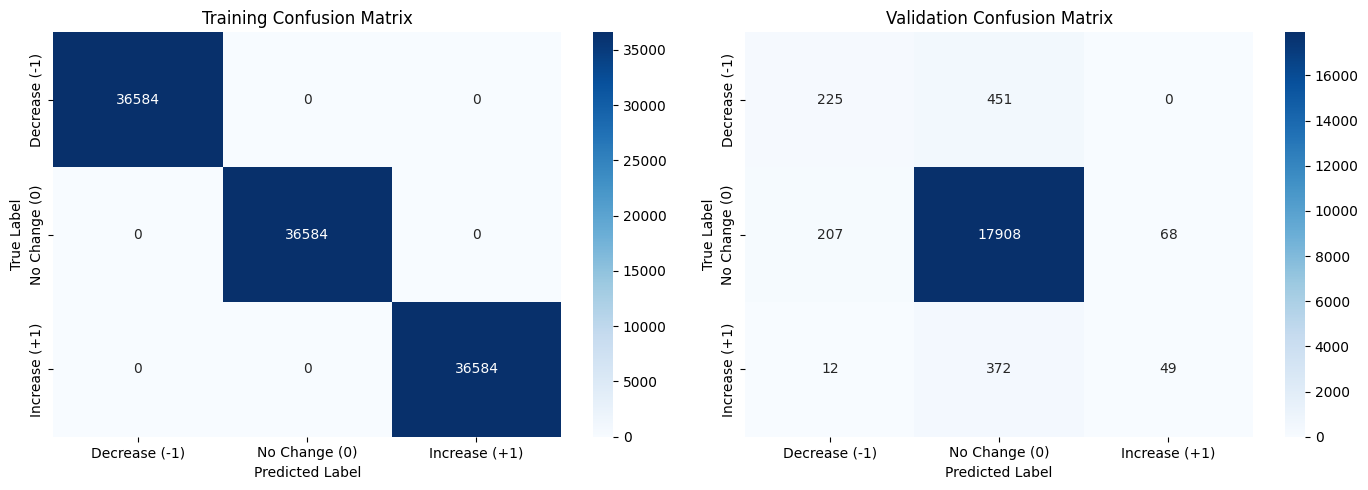

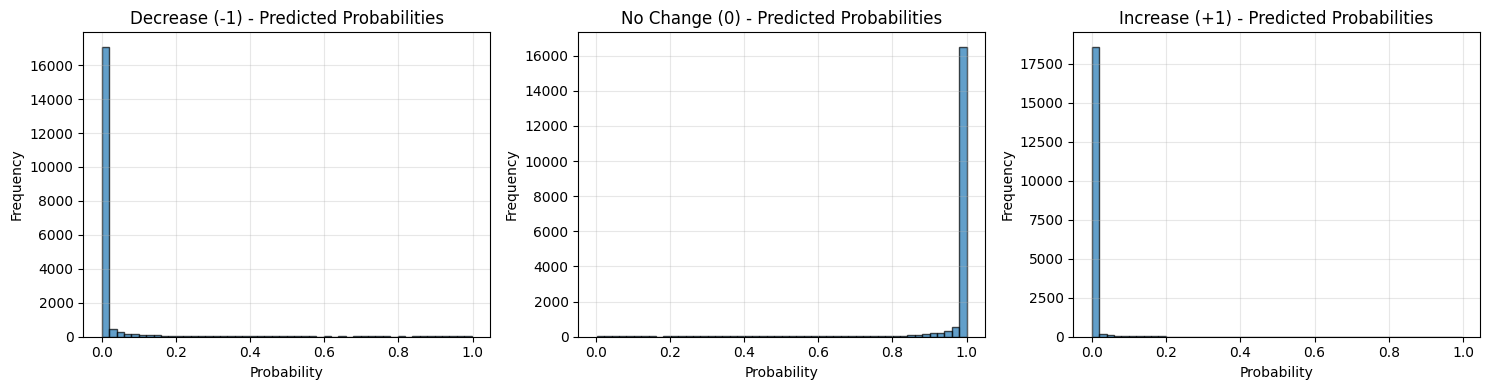

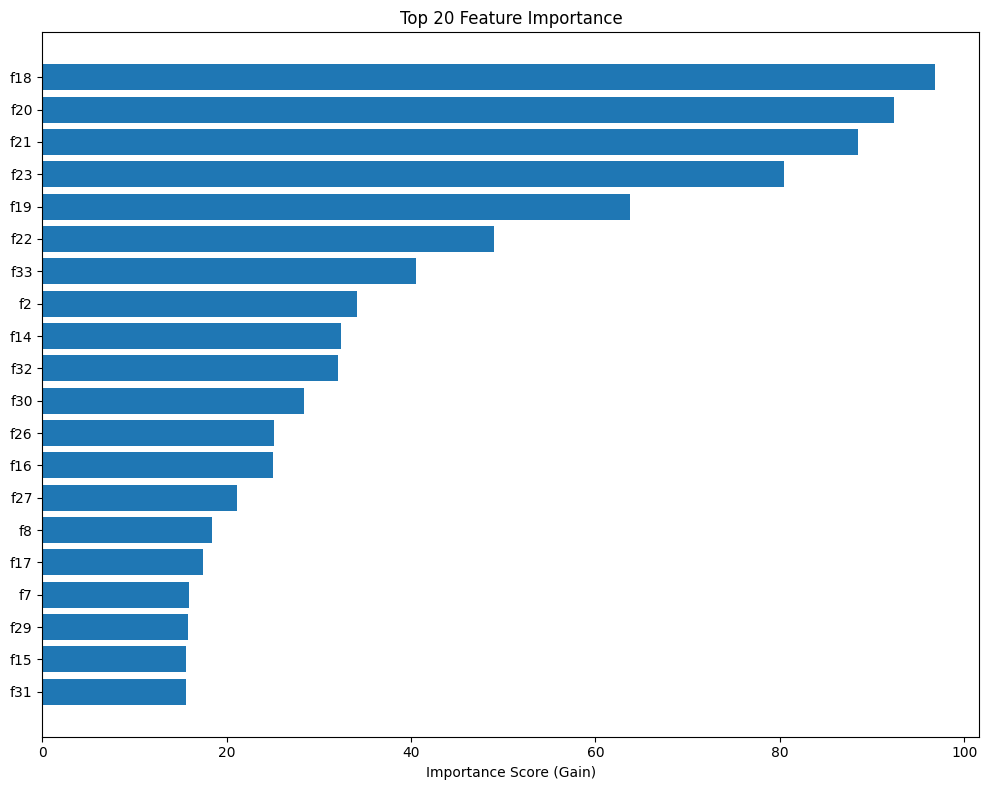


Top 10 Most Important Features:
1. f18: 96.82
2. f20: 92.42
3. f21: 88.45
4. f23: 80.49
5. f19: 63.79
6. f22: 48.97
7. f33: 40.51
8. f2: 34.08
9. f14: 32.38
10. f32: 32.05

PER-CLASS ANALYSIS

Decrease (-1):
  Samples: 676 (3.5%)
  Accuracy: 0.3328
  Avg Predicted Probability: 0.3470

No Change (0):
  Samples: 18183 (94.3%)
  Accuracy: 0.9849
  Avg Predicted Probability: 0.9759

Increase (+1):
  Samples: 433 (2.2%)
  Accuracy: 0.1132
  Avg Predicted Probability: 0.1266

Model saved to 'xgboost_multiclass_model.json'


In [36]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# 1. PREPARE DATA IN XGBOOST FORMAT
# ============================================================================

# Combine training data
X_train = np.vstack((X_site_a, X_site_c))
y_train = np.concatenate((y_site_a, y_site_c))

print(y_train.shape)
print(y_val.shape)

# ----------------------------------------------------------------------------
# OPTION 2: Use SMOTE (recommended for severe imbalance)
# ----------------------------------------------------------------------------
from imblearn.over_sampling import SMOTE
from collections import Counter

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Check new distribution
resampled_counts = Counter(y_train_resampled)
print(f"After SMOTE: {resampled_counts}")
print(f"Original samples: {len(y_train)} → Resampled: {len(y_train_resampled)}")

# Create DMatrix with resampled data
dtrain = xgb.DMatrix(X_train_resampled, label=y_train_resampled)
dval = xgb.DMatrix(X_val, label=y_val)

# ============================================================================
# 2. CONFIGURE HYPERPARAMETERS FOR MULTI-CLASS
# ============================================================================

params = {
    # Multi-class specific parameters
    'objective': 'multi:softprob',   # Multi-class with probability output
    'num_class': 3,                  # Number of classes (REQUIRED for multi-class)
    'eval_metric': ['mlogloss', 'merror'],  # Multi-class log loss and error rate
    
    # Tree parameters
    'max_depth': 6,
    'min_child_weight': 1,
    'gamma': 0,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    
    # Learning parameters
    'learning_rate': 0.1,
    
    # Regularization
    'reg_alpha': 0,
    'reg_lambda': 1,
    
    # System parameters
    'tree_method': 'hist',
    'random_state': 42,
    'n_jobs': -1,
}

# ============================================================================
# 3. TRAIN WITH EARLY STOPPING
# ============================================================================

evals = [(dtrain, 'train'), (dval, 'val')]

print("Training XGBoost multi-class model...")
model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=500,
    evals=evals,
    early_stopping_rounds=50,
    verbose_eval=50
)

print(f"\nBest iteration: {model.best_iteration}")
print(f"Best score: {model.best_score:.4f}")

# ============================================================================
# 4. MAKE PREDICTIONS
# ============================================================================

# Predict probabilities (returns shape: [n_samples, n_classes])
y_train_pred_proba = model.predict(dtrain)
y_val_pred_proba = model.predict(dval)

# Get predicted class (argmax across classes)
y_train_pred = np.argmax(y_train_pred_proba, axis=1)
y_val_pred = np.argmax(y_val_pred_proba, axis=1)

# ============================================================================
# 5. EVALUATE MODEL
# ============================================================================

# Define class names for better readability
class_names = ['Decrease (-1)', 'No Change (0)', 'Increase (+1)']
# Or if already mapped: class_names = ['Class 0', 'Class 1', 'Class 2']

print("\n" + "="*60)
print("TRAINING SET PERFORMANCE")
print("="*60)
print(f"Accuracy: {accuracy_score(y_train_resampled, y_train_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_train_resampled, y_train_pred, 
                          target_names=class_names, 
                          digits=4))

print("\nConfusion Matrix:")
cm_train = confusion_matrix(y_train_resampled, y_train_pred)
print(cm_train)

print("\n" + "="*60)
print("VALIDATION SET PERFORMANCE")
print("="*60)
print(f"Accuracy: {accuracy_score(y_val, y_val_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred, 
                          target_names=class_names, 
                          digits=4))

print("\nConfusion Matrix:")
cm_val = confusion_matrix(y_val, y_val_pred)
print(cm_val)

# ============================================================================
# 6. VISUALIZE CONFUSION MATRIX
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training confusion matrix
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Training Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Validation confusion matrix
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Validation Confusion Matrix')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 7. CLASS-WISE PROBABILITY DISTRIBUTION
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for class_idx in range(3):
    axes[class_idx].hist(y_val_pred_proba[:, class_idx], bins=50, alpha=0.7, edgecolor='black')
    axes[class_idx].set_title(f'{class_names[class_idx]} - Predicted Probabilities')
    axes[class_idx].set_xlabel('Probability')
    axes[class_idx].set_ylabel('Frequency')
    axes[class_idx].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('probability_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 8. FEATURE IMPORTANCE
# ============================================================================

importance_dict = model.get_score(importance_type='gain')
feature_importance = sorted(importance_dict.items(), key=lambda x: x[1], reverse=True)

fig, ax = plt.subplots(figsize=(10, 8))
features = [f[0] for f in feature_importance[:20]]
scores = [f[1] for f in feature_importance[:20]]

ax.barh(features, scores)
ax.set_xlabel('Importance Score (Gain)')
ax.set_title('Top 20 Feature Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTop 10 Most Important Features:")
for i, (feat, score) in enumerate(feature_importance[:10], 1):
    print(f"{i}. {feat}: {score:.2f}")

# ============================================================================
# 9. PER-CLASS METRICS
# ============================================================================

print("\n" + "="*60)
print("PER-CLASS ANALYSIS")
print("="*60)

for class_idx in range(3):
    class_mask = y_val == class_idx
    class_accuracy = accuracy_score(y_val[class_mask], y_val_pred[class_mask])
    class_count = np.sum(class_mask)
    
    print(f"\n{class_names[class_idx]}:")
    print(f"  Samples: {class_count} ({100*class_count/len(y_val):.1f}%)")
    print(f"  Accuracy: {class_accuracy:.4f}")
    print(f"  Avg Predicted Probability: {y_val_pred_proba[class_mask, class_idx].mean():.4f}")

# ============================================================================
# 10. SAVE MODEL
# ============================================================================

model.save_model('xgboost_multiclass_model.json')
print("\nModel saved to 'xgboost_multiclass_model.json'")

# Save label mapping for later use
np.save('label_mapping.npy', np.array([{-1: 0, 0: 1, 1: 2}]))